# **Mestrado em Informática**
## *Aprendizagem Máquina*

# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*
Mónica Vieira Martins
---------

># Pré-processamento. Treinar e avaliar um modelo de Regressão Logística.

Lidar com valores ausentes  e com variáveis categóricas.
Subconjuntos de treino e de teste. Regressão Logística.
Avaliação de modelos de classificação.


# Introdução: pré-processamento dos dados


Alguns aspetos dos dados que devem ser tidos em conta antes de iniciar o treino/teste de um modelo:

*   As variáveis independentes (atributos) devem ser independentes umas das outras (não deve haver correlação forte entre as variáveis independentes).  
*   Não deve haver valores em falta nos dados.
*   Para um número significativo de algoritmos, as variáveis têm que ser numéricas.
*   Para assegurar que o resultado é fiável, o conjunto de dados deve ser volumoso. Como regra intuitiva, devem existir pelo menos 50 observações por cada variável independente.

Adicionalmente, se o problema é de classificação:
*   A variável dependente (alvo) é binária ou ordinal.

Este tutorial revê alguns passos fundamentais de  pré-processamento de dados, introduz o conceito de dados de treino e dados de teste, exemplifica o processo de treino e de teste e de avaliação do modelo com as métricas comuns.


# Dados

Neste tutorial vamos utilizar o conjunto de dados referente aos passageiros do [Titanic](https://https://www.kaggle.com/c/titanic/data). Trata-se de um conjunto de dados disponibilizado pela plataforma [Kaggle](https://www.kaggle.com).
O objetivo é exemplificar o processo completo de criação e avaliação de um modelo de aprendizagem máquina, neste caso usando a regressão logística.

O ficheiro de dados denomina-se `Titanic.csv`. A descrição das colunas do ficheiro é a seguinte:

>Variável | Significado | Valores
>---------|-------------|---------
>Survival | sobrevivência | 0=Não, 1=Sim  |
>Pclass | classe do bilhete | 1=1ª, 2=2ª, 3=3ª|
> Name | nome | |
>Sex | sexo | male, female |
>Age | idade, em anos | |
>Sibsp | número de irmãos/esposos a bordo||
>Parch | número de pais/filhos a bordo |
>Ticket |	número do bilhete |
>Fare | preço pago  |
> Embarked | porto de embarcação | C=Cherbourg, Q=Queenstown, S=Southampton




In [1]:
#Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
import numpy as np

In [2]:
'''
Uma das possibilidade de fazer upload de ficheiros no colab é através do código abaixo
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('Uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
'''

'''
Alternativamente,    fazer o upload do ficheiro arrastando-o para a pasta que
se abre quando se seleciona separador Ficheiros, no painel à esquerda. O ficheiro
ficará na pasta \content


'''

'\nAlternativamente,    fazer o upload do ficheiro arrastando-o para a pasta que\nse abre quando se seleciona separador Ficheiros, no painel à esquerda. O ficheiro\nficará na pasta \\content\n\n\n'

In [3]:
#adequar o path do ficheiro
path = "titanic.csv"
dados = pd.read_csv(path)

## Análise prévia dos dados

In [4]:
dados.shape

(891, 12)

Vemos que o conjunto de dados possui 891 entradas e 12 atributos.  
Mesmo que usássemos os 12 atributos, o número de entradas seria suficiente para garantir que o conjunto de dados é suficientemente volumoso para aplicação da regressão logística.

In [5]:
dados.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
dados.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


*PassengerID* e índice são redundantes, podemos alterar o índice com `set_index()`

In [7]:
dados.set_index('PassengerId', inplace=True, drop=True)
dados.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


De acordo com a análise realizada no 1º semestre, vamos desconsiderar os atributos *Name* , *Ticket* e *Cabin*


In [8]:
dados.drop(columns=['Name','Ticket','Cabin'], inplace=True)
dados.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


In [9]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.6+ KB


Vemos que para a maior parte dos atributos existem 891 entradas, mas para a idade (`Age`), cabine (`Cabin`) e porto de embarque  (`Embarked`) o número é menor, o que significa que existem **valores nulos ou omisso**. Teremos portanto que decidir como lidar com estes atributos.

Também verificamos que algumas dos atributos (`Name`, `Sex`, `Ticket`, `Cabin` e `Embarked` ) não estão expressas em valores numéricos. Tratam-se de **variáveis categóricas**. Veremos mais à frente como lidar com este tipo de variáveis.   

Vamos utilizar como variável independente, ou **alvo**, a variável `Survived`. Vejamos os valores possíveis dessa variável :

In [10]:
dados.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Trata-se de uma variável binária, adequada, portanto, à utilização como alvo num modelo de regressão logística binário.  



A percentagem de passageiros que se salvaram foi pequena:

In [11]:
#Pencentagem de sobreviventes:
survived  = dados.Survived[dados.Survived==1].count() / dados.Survived.count()*100
print("Percentagem de sobreviventes: %.0f%%"%(survived))

Percentagem de sobreviventes: 38%


In [12]:
#Carateristicas dos atributos numéricos
dados.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Podemos  ter uma noção abrangente das variáveis observando o resultado do *pairplot* (variáveis numéricas), aqui obtido usando `sns.pairplot` e com cores diferentes para a distribuição de cada uma das classes:

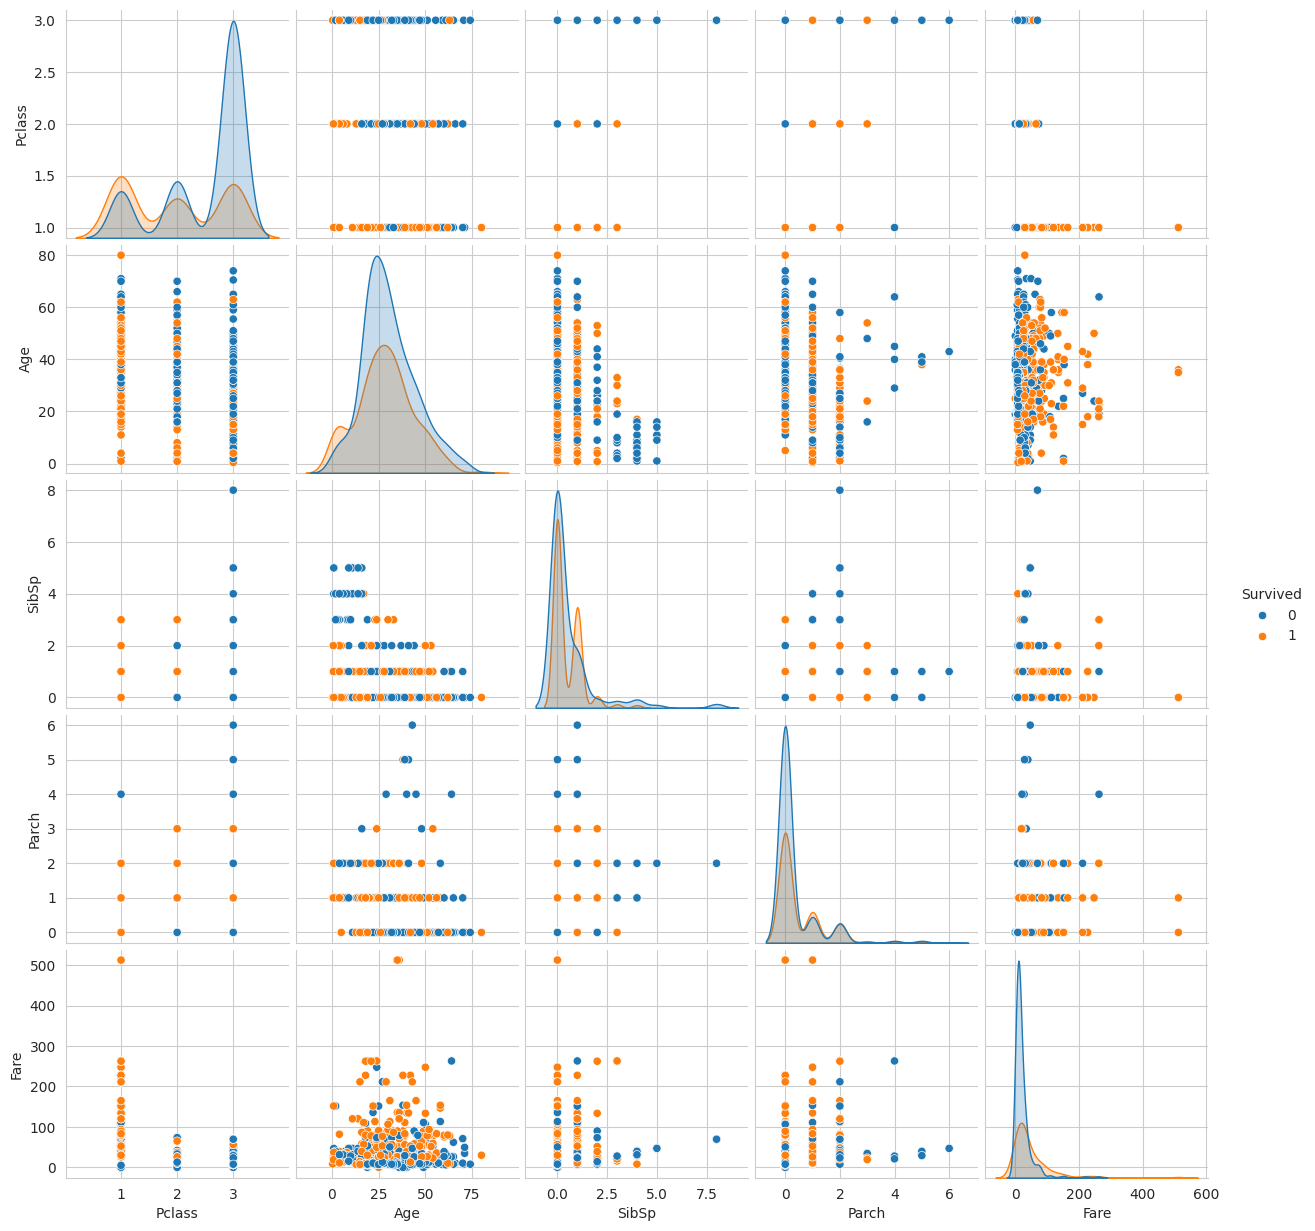

In [13]:
sns.pairplot(dados, hue="Survived")

O *pairplot*  permite algumas interpretações que exploramos melhor mais à frente, nomeadamente relativos à classe, idade, sexo.

Verifiquemos, agora, a correlação entre as variáveis numéricas:


<Axes: >

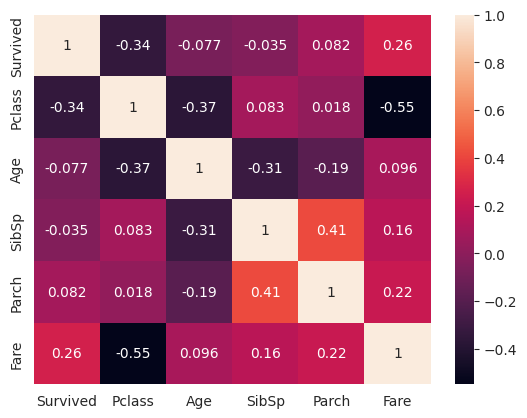

In [14]:
#selecinoar  os atributos numéricos
dados_num = dados.select_dtypes(include='number')
#correlação entre os atributos numéricos e visualização em heatmap
sns.heatmap(dados_num.corr(), annot=True)

Uma vez que os valores de correlação são baixos em termos absolutos (exceto a auto-correlação, na diagonal principal, que é sempre 1),  **as variáveis numéricas não estão correlacionadas entre si**, sendo portanto adequadas para serem usadas como variáveis independentes na criação de um modelo de regressão logística.  
Também se observa que nenhuma das variáveis numéricas tem um elevado coeficiente de correlação com o alvo, o que só por si pode indicar que a tarefa de classificação não é óbvia.


Repetimos aqui alguns dos passos de pré-processamento que foram apresentados na UC do 1º semestre. 
O primeiro desses passos é agrupar os dados dos números de familiares numa única coluna de dados.

In [15]:
#Criar nova coluna de dados
dados["FamilySize"]=dados.Parch+dados.SibSp

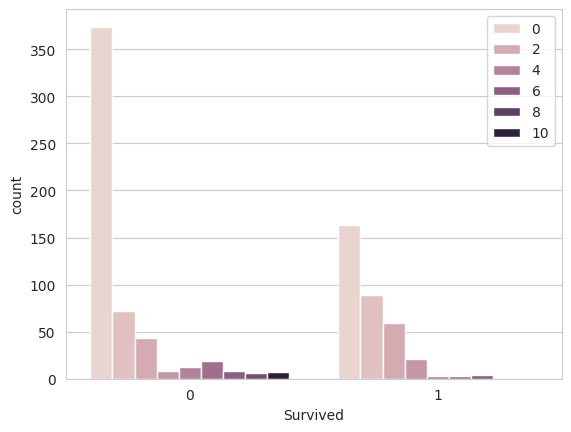

In [16]:
#Observar a distribuição de FamilySize
sns.countplot(x='Survived', hue='FamilySize', data=dados)
plt.legend(loc='upper right')

In [17]:
#retirar os atributos Parch, SibSp e PassengerID
dados.drop(["Parch","SibSp"], axis=1, inplace=True)

## Evitar vazamento de dados

Antes de se passar ao pré-processamento de dados é necessário garantir que se evita o vazamento de dados (*data leakage*).

O vazamento de dados ocorre sempre que os dados de treino/modelo obtêm algum tipo de informação sobre os dados de teste, e estes passam a não ser completamente desconhecidos pelo modelo.

É importante, então, que a separação dos dados entre subconjunto de treino e  de teste anteceda os passos de pré-processamento, pois, de outra forma poderá ocorrer vazamento de dados.


Portanto, comecemos por separar os dados em conjunto de treino e conjunto de teste antes de passar ao pré-processamento dos dados.

In [18]:
#separar a variável independente (alvo) das variáveis dependentes
y = dados.Survived
dados.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
PassengerId,,,,,,,
1,0,3,male,22.0,7.2500,S,1
2,1,1,female,38.0,71.2833,C,1
3,1,3,female,26.0,7.9250,S,0
4,1,1,female,35.0,53.1000,S,1
5,0,3,male,35.0,8.0500,S,0


In [19]:
#criar o conjunto de variáveis independentes
X = dados.drop(['Survived'], axis=1)

In [20]:
#criar subconjuntos para treino e teste
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=0)

In [21]:
print(Xtrain.shape)
print(Xtest.shape)

(712, 6)
(179, 6)


## Lidar com valores ausentes

Para lidar com valores ausentes iremos usar a **Imputação** . No caso da percentagem de valores ausentes ser muito elevada, iremos simplesmente desconsiderar a coluna respetiva, apagando-a dos dados.  
Recorde-se que a  **Imputação** é o  método estatístico para o tratamento de valores ausentes, substituindo-se os mesmos pelas suas estimativas. Como estimativa utiliza-se a média, a mediana ou o valor mais frequente.


Comecemos por recordar quais são os atributos com dados ausentes e calcular as respetivas percentagens:

In [22]:
Xtrain.isna().sum()

Pclass          0
Sex             0
Age           141
Fare            0
Embarked        2
FamilySize      0
dtype: int64

In [23]:
# #percentagem de dados omissos do atributo "Cabin"
# omissos_cabin =Xtrain.Cabin.isna().sum()/Xtrain.Cabin.isna().count()*100
# print("Dados omissos em Cabin: %.0f%%" %omissos_cabin)

Há cerca de 77% dos valores de "Cabin" em falta. Esta é uma percentagem demasiado grande para poder ser substituída por qualquer outro valor, por isso vamos simplesmente não incluir este atributo no treino do nosso modelo.

Excluímos a coluna respetiva nos dados de treino e nos dados de teste.

In [24]:
#retirar o atributo "Cabin" dos conjuntos de treino e teste
#Xtrain = Xtrain.drop(['Cabin'], axis=1)

In [25]:
Xtrain.shape

(712, 6)

In [26]:
#percentagem de dados ausentes do atributo "Age"
ausentes_age = Xtrain.Age.isna().sum() / Xtrain.Age.count() * 100
print("Dados ausentes em Age: %.0f%%" %ausentes_age)

Dados ausentes em Age: 25%


Já relativamente a Age, apenas existem 25% de dados omissos, pelo que vale a pena usar a estratégia da imputação nesta coluna. Para já, vamos utilizar a imputação simples utilizando a média como estimativa. Posteriormente, iremos explorar as restantes estratégias disponíves.

### Imputação de dados -  Simple Imputer



Para substituição dos valores ausentes, vamos utilizar a classe `SimpleImputer`,  disponível na biblioteca `scikit-learn`. No construtor da classe há que definir a estratégia que vai ser usada para estimar o valor dos dados ausentes.
A estratégia possíveis são as seguimtes:
* **média** - definida por omissão; usada apenas com dados numéricos;
* **mediana**  - usada apenas com dados numéricos;;
* **valor mais frequente** - usada tanto para dados numéricos como categóricos;
*  **valor constante**,  a definir pelo utilizador - usada tanto para dados numéricos como categóricos;


**IMPORTANTE:**  

Os objetos da classe SimpleImputer possuem um método  `fit_transform()` e um método ``transform()``.
* `fit_transform()`  - calcula e aplica o valor definido pela estratégia usada; usa-se apenas no subconjunto de treino
* ``transform()`` -  aplica o valor calculado; usa-se no subconjunto de teste.

Ao usar-se ``fit_transform()`` apenas nos dados de treino, **evita-se o fenómeno de vazamento de dados**, pois garante-se que não é usada informação presente nos dados de teste.

A informação mais completa sobre o SimpleImputer pode ser consultada em  https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html.



#### `SimpleImputer()` na prática

A estratégia a usar na imputação poderá ser diferente para os dados numéricos e para os dados categóricos.

Então, por conveniência, separam-se os subconjuntos de treino e teste apenas para as variáveis numéricas, e, posteriormente, apenas para as variáveis categóricas. 

In [27]:
#Seleção dos atributos numéricos
Xtrain_numeric = Xtrain.select_dtypes(include=['int64', 'float64'])
Xtest_numeric = Xtest.select_dtypes(include=['int64', 'float64'])

In [28]:
print(Xtrain_numeric.shape)
print(Xtest_numeric.shape)

(712, 4)
(179, 4)


In [29]:
#Aplicação do Imputer 
from sklearn.impute import SimpleImputer

#Criar o objecto my_imputer usando a média como estratégia
myImputer = SimpleImputer(strategy='mean')

# calcular e aplicar a Xtrain a média usando  fit_transform()
#fit_transform()  devolve um  array, que convertemos num DataFrame
Xtrain_num_imp = pd.DataFrame(myImputer.fit_transform(Xtrain_numeric))

#Agora, usar o transform() com os dados de teste
Xtest_num_imp = pd.DataFrame(myImputer.transform(Xtest_numeric))

#O Imputer retira o nome das colunas, vamos colocá-las de volta:
Xtrain_num_imp.columns = Xtrain_numeric.columns
Xtest_num_imp.columns = Xtest_numeric.columns

#O Imputer reformula o índice, vamos colocar o original:
Xtrain_num_imp.index = Xtrain_numeric.index
Xtest_num_imp.index = Xtest_numeric.index


In [30]:
Xtrain_num_imp.head()

,Pclass,Age,Fare,FamilySize
PassengerId,,,,
141,3.0,29.745184,15.2458,2.0
440,2.0,31.000000,10.5000,0.0
818,2.0,31.000000,37.0042,2.0
379,3.0,20.000000,4.0125,0.0
492,3.0,21.000000,7.2500,0.0


Confirmemos que já não existem valores numéricos omissos:  

In [31]:
print("TRAIN: ")
print(Xtrain_num_imp.isna().sum())
print("\nTEST:");
print(Xtest_num_imp.isna().sum())

TRAIN: 
Pclass        0
Age           0
Fare          0
FamilySize    0
dtype: int64

TEST:
Pclass        0
Age           0
Fare          0
FamilySize    0
dtype: int64


Resta o atributo `Embarked`, não numérico, que possui 2 valores omissos.  
Comecemos então por criar o subconjunto de variáveis categóricas.

In [32]:
Xtrain_cat = Xtrain.select_dtypes(include ='object')
Xtest_cat = Xtest.select_dtypes(include ='object')
Xtrain_cat.head()

,Sex,Embarked
PassengerId,,
141,female,C
440,male,S
818,male,C
379,male,C
492,male,S


Podemos usar o `SimpleImputer`, mas, como não se tratam de valores numéricos, não podemos usar a média ou mediana como estratégia. Aqui faz algum sentido usar o valor mais frequente dos três posíveis (S,C,Q).


In [33]:
#Criar o objecto my_imputer usando a moda como estratégia
myImputer = SimpleImputer(strategy='most_frequent')

#usar o imputer separadamente no treino e teste.
Xtrain_cat_imputed = pd.DataFrame(
    myImputer.fit_transform(Xtrain_cat),
    columns=Xtrain_cat.columns,
    index=Xtrain_cat.index)

Xtest_cat_imputed = pd.DataFrame(
    myImputer.transform(Xtest_cat), 
    columns=Xtest_cat.columns, 
    index=Xtest_cat.index)

Verificar que já não existem valores omissos ebtre as colunas de dados categóricos:

In [34]:
print("TRAIN: ")
print(Xtrain_cat_imputed.isna().sum())
print("\nTEST: ")
print(Xtest_cat_imputed.isna().sum())

TRAIN: 
Sex         0
Embarked    0
dtype: int64

TEST: 
Sex         0
Embarked    0
dtype: int64


Verificar como foram distribuídos os valores imputados:

In [35]:
print("Xtrain - before imputation")
print(Xtrain_cat["Embarked"].value_counts())
print("\nXtrain - after imputation")
print(Xtrain_cat_imputed["Embarked"].value_counts())

Xtrain - before imputation
Embarked
S    517
C    129
Q     64
Name: count, dtype: int64

Xtrain - after imputation
Embarked
S    519
C    129
Q     64
Name: count, dtype: int64


Antes de se iniciar o  treino do modelo, há ainda que transformar as variáveis categóricas, uma vez que para a regressão logística, como para muitos outros algoritmos de aprendizagem máquina, os dados apenas podem conter variáveis numéricas.

## Transformar variáveis categóricas

Muitos dos algoritmos de aprendizagem máquina funcionam apenas com variáveis do tipo numérico. Assim, é necessário, antes de treinar o modelo, decidir como lidar com  as **variáveis categóricas**.

Há duas abordagens possíveis:
1. Não utilizar  colunas não numéricas. Evidentemente, esta abordagem tem que ser equacionada com cautela, porque se poderá estar a desprezar informação valiosa.  
2.  Transformar as variáveis categóricas em informação numérica, ou seja, **codificar** as variáveis categóricas.


A biblioteca *scikit learn* disponibiliza 2 tipo de **codificadores** (*encoders*) para codificar numericamente variáveis categóricas:

1.  **Label Encoder** : Acrescenta uma coluna ao dados, atribuindo um valor numérico inteiro a cada um dos valores únicos do atributo em questão. Por exemplo, se o atributo for "país" e o valores forem "Portugal", Espanha" e "França", o LabelEncoder acrescentaria uma nova coluna, preenchida com 0 para o caso de "Portugal", 1 para o caso de "Espanha" e 2 para o caso de "França".
A desvantagem desta abordagem é que, posteriormente, o algoritmo de aprendizagem máquina pode considerar que existe alguma ordem no valor do atributo (por exemplo, 0 ser mais importante que 1, mais importante que 2, ou o inverso), o que pode não corresponder à realidade.
2.    **OneHotEncoder** (*One Out of N Encoder*): utilizado quando  se quer  garantir que não há interpretação relativa à ordem do valor codificado. O OneHotEncoder acrescenta aos dados tantas colunas quanto a cardinalidade (o número de valores possíveis) da variável a codificar, atribuindo o valor 1 à coluna que representa o valor em causa, e 0 às restantes.
No exemplo do atributo "país" usado em cima, os dados codificados pelo OneHotEncoder teriam três coluna extra; quando o valor fosse "Portugal", a primeira coluna teria 1 e as restantes 0; se fosse "Espanha", a 2ª coluna teria 1 e as restantes 0, e por aí fora.
A desvantagem do OneHotEncoder é que, se a **cardinalidade** for elevada e/ou o número de variáveis categóricas for elevado, o resultado pode ser um conjunto de dados com um número muito elevado de novas colunas. Por isso, o OneHotEncoder é usado sobretudo para variáveis de baixa cardinalidade.




Voltemos então ao nosso subconjunto de dados não numéricos, e analisemos a adequabilidade  das opções disponíveis

As colunas `Sex` e `Embarked` podem ser facilmente codificadas em variáveis numéricas, porque a sua cardinalidade é baixa (2 e 3, respetivamente). Para tal, iremos usar o **OneHotEncoder**

In [36]:
Xtrain_cat_imputed.head()

,Sex,Embarked
PassengerId,,
141,female,C
440,male,S
818,male,C
379,male,C
492,male,S


Começamos por criar o objeto da classe **OneHotEncoder**, usamos o *fit_transform()* nos dados de treino, para determinar os parâmetros, e depois o *transform()* nos dados de teste.

A documentação sobre o OneHotEncoder pode ser encontrada em https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html


In [37]:
#One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False, drop='first')

No construtor, usou-se `first` como parâmetro para `drop`, porque, embora o OneHotEncoder crie N colunas para cada variável (sendo N a cardinalidade da variável), os valores ficam perfeitamente definidos com apenas N-1 colunas.

Por exemplo, `Sex`, que tem cardinalidade 2, fica completamente definido apenas com uma coluna, em que um género é definido por 1, o outro género definido por 0.

O mesmo é válido para atributos de maior cardinalidade.

Usou-se `sparse_output=False` para obtenção de uma `np.array` e não uma matriz esparsa, que implicaria maior complexidade para ser transformada num `DataFrame`

Em seguida, usa-se o *fit_transform()*:

In [38]:
#nome das colunas que vão ser adicionadas
colunas=["Sex", "Embarked_1","Embarked_0"]

#Aplicar o One-Hot Encoder ao treino e teste
Xtrain_cat_ohe=pd.DataFrame (
    ohe.fit_transform(Xtrain_cat_imputed),
    index = Xtrain_cat_imputed.index,
    columns = colunas)

Xtest_cat_ohe=pd.DataFrame (
    ohe.transform(Xtest_cat_imputed),
    index = Xtest_cat_imputed.index,
    columns = colunas)

In [39]:
Xtrain_cat_ohe.head(8)


,Sex,Embarked_1,Embarked_0
PassengerId,,,
141,0.0,0.0,0.0
440,1.0,0.0,1.0
818,1.0,0.0,0.0
379,1.0,0.0,0.0
492,1.0,0.0,1.0
332,1.0,0.0,1.0
589,1.0,0.0,1.0
359,0.0,1.0,0.0


In [40]:
Xtrain_cat_imputed.head(8)

,Sex,Embarked
PassengerId,,
141,female,C
440,male,S
818,male,C
379,male,C
492,male,S
332,male,S
589,male,S
359,female,Q


Comparando Xtrain antes e depois da aplicação do OneHotEncoder, verifica-se:
* relativamente a *Sex*:  `female` foi codificado com `1`, `male` com `0`.
* relativamente a *Embarked*: `C` foi codificado com `00`; `S` foi codificado com `01`, e `Q` foi codificado com `10`.

Por fim, usamos o método `join()` resta juntar as colunas de dados numéricos às colunas de dados categóricos para obter o conjunto de dados com os quais  posteriormente   se treinará e testará o modelo.

In [41]:
Xtrain_final = Xtrain_num_imp.join(Xtrain_cat_ohe)
Xtest_final = Xtest_num_imp.join(Xtest_cat_ohe)

In [42]:
print(Xtrain_final.shape)
print(Xtest_final.shape)

(712, 7)
(179, 7)


In [43]:
Xtrain_final.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
PassengerId,,,,,,,
141,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0
440,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0
818,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0
379,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0
492,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0


# Treinar o modelo de regressão logística

Depois de todo este pré-processamento, os dados estão  em condições de serem usados para treinar. Vai ser treinado um modelo de regressão logística, processo que se revela muito simples. Seguem-se os passos semelhantes aos  indicados no tutorial anterior para treinar modelos.  

A documentação sobre a regressão logísica em *scikit learn* pode ser consultada em https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html




In [44]:
#Regressão Logística.
from sklearn.linear_model import LogisticRegression
log_r = LogisticRegression(max_iter=250)

#Criar e treinar o modelo de regressão logística
log_r.fit(Xtrain_final, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,250
,multi_class,'deprecated'


# Avaliar o  modelo

Com o modelo criado, é necessário avaliá-lo para ter uma ideia da sua qualidade.
As métricas a utilizar terão necessariamente que ser diferente das usadas para os problemas de regressão.

Uma das métricas mais importantes para problemas de classificação é a **exatidão** (em inglês, **accuracy**). De uma forma simples, a exatidão indica a frequência com que o modelo de classificação, ou classificador,  fornece uma resposta correta.
É calculada como o quociente entre a soma dos exemplos corretamente identificados e o total dos exemplos. Assim, o seu valor está compreendido entre 0 e 1, sendo que a este último corresponde 100% de respostas corretas.



Pode-se ter uma ideia se um  classificador está em **overfitting**, ou seja, se não está a generalizar corretamente,   comparando a exatidão relativa aos dados de treino e a exatidão relativa aos dados de teste. O classificador estará em overfitting se a exatidão obtida com os dados de treino tiver um valor relativamente elevado e for muito superior à exatidão obtida com os dados de teste, porque isso significa que o modelo classifica muito bem os dados que já conhece, mas o que aprendeu não lhe permite  generalizar  suficientemente bem para dados que não conhece.

Vejamos então como se comporta o modelo treinado. Para calcular a exatidão usamos
o método `accuracy_score` disponível em *scikit learn*.

In [45]:
#medir a exatidão do modelo
acc = log_r.score(Xtrain_final, ytrain)
print("Exactidão medida nos dados de  treino: %.2f" %acc)

Exactidão medida nos dados de  treino: 0.80


In [46]:
from sklearn.metrics import accuracy_score
#Realizar as predições e medir a exatidão com os dados de teste

#gerar os valores preditivos para Xtest
ypred = log_r.predict(Xtest_final)

#medir a exatidão para ytrain
acc_test = accuracy_score(ytest, ypred)
print("Exactidão medida nos dados de teste: %.2f" %acc_test)


Exactidão medida nos dados de teste: 0.81


Embora não seja muito elevada, a exatidão calculada com os dados de teste é semelhante à exatidão obtida com os dados de treino, por isso o modelo treinado está a generalizar bem.

Pode-se aprofundar um pouco mais a análise da qualidade do classificador criado. Pode-se, por exemplo, colocar a seguinte questão: será que o  modelo classifica com igual qualidade as duas classes (sobreviventes / não sobreviventes)?   

Será interessante conhecer as seguintes quantidades :   

*   Verdadeiros positivos (VP): quantidade de valores positivos classificados como positivos
*   Verdadeiros negativos (VN): quantidade de valores negativos classificados como negativos
*   Falsos positivos (FP) : quantidade de valores negativos classificados como positivos
*   Falsos negativos (FN) : quantidade de  valores positivos classificado como negativos.

Repare-se que a exatidão pode ser calculada por (VP+VN)/total

As quantidades mencionadas podem ser visualizadas numa *matriz de confusão*

![ConfMatrix](https://drive.google.com/uc?export=view&id=1qWuW4_YfqSs7_jO18-dU0mQYJmK1kL24)

Nota: no presente caso, considere-se negativo a não sobrevivência (0) e como positivo a sobrevivência (1).


O método `confusion_matrix()` devolve um array com VN, FP, FN, VP.
Documentação em https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html



In [47]:
from scipy.sparse import csc_matrix
from sklearn.metrics import confusion_matrix

#criar a matriz de confusão


#o 1º argumento são os valores verdadeiros,
#o 2º argumento são os valores previstos
conf_matrix = confusion_matrix(ytest, ypred)

In [48]:
ytest.value_counts()

Survived
0    110
1     69
Name: count, dtype: int64

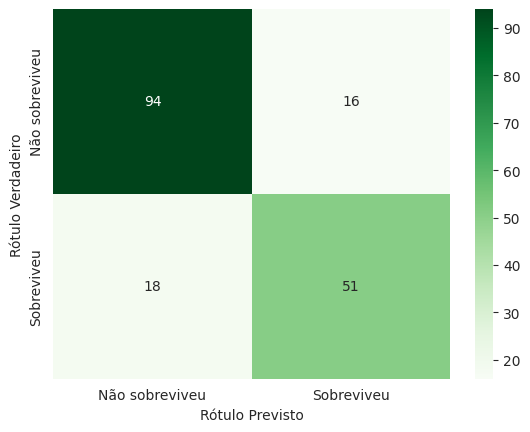

In [49]:
#visualizar a matriz de confusão
rotulos=["Não sobreviveu", "Sobreviveu"]
s = sns.heatmap(conf_matrix, annot=True, cmap="Greens",
              xticklabels=rotulos, yticklabels=rotulos)
# a matrix devolvida contém os valores verdadeiros em y e os
#valores previstos em x
s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro")

plt.show()

Repare-se que:
*  a soma da 1ª linha é o número de 0's (não sobreviveu) em ytest
* a soma da 2ª linha é o número de 1's (sobreviveu)
 em ytest  
* a diagonal principal tem os valores corretamente classificados em cada um dos rótulos (Verdadeitos Positivos (VP) e Verdadeiros Negativos (VN)
* os elementos fora da diagonal são os classificados incorretamente (Falsos Positivos e Falsos Negativos)  

In [50]:
VN, FP, FN, VP =conf_matrix.ravel()
print("Verdadeiros Negativos: %d" %VN)
print("Falsos Positivos: %d" %FP)
print("Falsos Negativos: %d" %FN)
print("Verdadeiros Positivos: %d" %VP)

Verdadeiros Negativos: 94
Falsos Positivos: 16
Falsos Negativos: 18
Verdadeiros Positivos: 51


A exatidão é 0,81, como tínhamos previamente determinado.


In [51]:
acc=(VP+VN)/(VP+VN+FP+FN)
print("Exatidão (teste) %.2f" %acc)

Exatidão (teste) 0.81


Outra forma de criar a matriz de confusão, com valores normalizados relativamente às linhas (ou seja, aos rótulos verdadeiros):


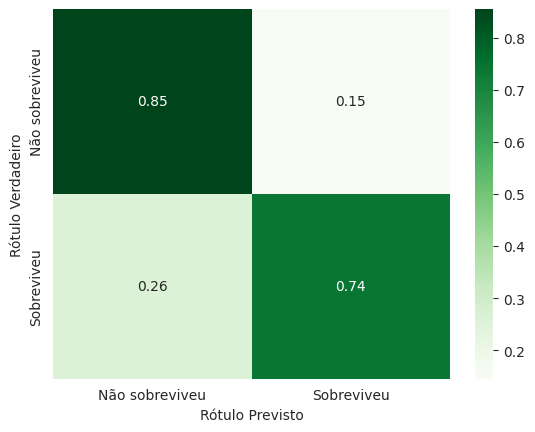

In [52]:
#visualizar a matriz de confusão
rotulos=["Não sobreviveu", "Sobreviveu"]
conf_matrix =  confusion_matrix(ytest, ypred, normalize="true")
s = sns.heatmap(conf_matrix, annot=True, cmap="Greens",
              xticklabels=rotulos, yticklabels=rotulos)
# a matrix devolvida contém os valores verdadeiros em y e os
#valores previstos em x
s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro")

plt.show()

Esta formulação torna mais evidente que o classificador tem mais dificuldade em classificar corretamente os sobreviventes (26% de falsos negativos) do que os não sobreviventes (15% de falsos positivos).

Em parte, isto deve-se a que a classe "Sobreviveu" é a classe minoritária  - tinha sido verificado inicialmente que apenas 40% dos elementos pertenciam a essa classe. O modelo possui assim uma tendência para classificar melhor os exemplos que conhece melhor - ou seja, os exemplos que existem em maior número nos dados com que foi treinado.

Este problema é conhecido como o não balanceamento de dados, e ocorre sempre que uma das classes está significativamente mais representada nos dado. Existem técnicas para lidar com esta questão, mas que estão fora do âmbito desta disciplina.

A exatidão é uma métrica global. Existem outras métricas para avaliar classificadores (precisão, recall, F1-score), e permitem melhor compreender a performance do modelo para cada uma das classes envolvidas.  

![ConfMat+F1](https://drive.google.com/uc?export=view&id=1MbJ1ugLygR5cHiukliqoVtO_YP7qFWdq)

Na imagem anterior as métricas estão expressas em inglês (para reconhecimento na literatura de `sklearn`) e podem ser traduzidas da seguinte forma:
* precision : precisão
* recall: sensibilidade
* accuracy: exatidão

A precisão, sensibilidade e F1 podem ser calculadas individualmente para cada classe. Já a exatidão é uma medida global.

Estas métricas são facilmente obtidas usando o método  `classification_report()`.

In [53]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(ytest,ypred))


              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Gravar os dados para posterior utilização

In [54]:
train = pd.concat([Xtrain_final, ytrain], axis=1)
test = pd.concat([Xtest_final, ytest], axis=1)

In [55]:
train.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0,Survived
PassengerId,,,,,,,,
141,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0,0
440,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0,0
818,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0,0
379,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0,0
492,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0,0


In [56]:
train.shape

(712, 8)

In [57]:
test.shape

(179, 8)

In [58]:
#gravar dados para usar  noutros notebooks
train.to_csv("titanic_train.csv", sep=',', index=False)
test.to_csv("titanic_test.csv", sep=',', index=False)